## Homework Assignment #3

In this assignment, you need to implement loss functions for linear regression and their derivatives with respect to parameters, __without using automatic differentiation.__ All methods must be implemented using only the `numpy` library.

Your main task: derive formulas for the derivatives of __MSE, MAE, L1 and L2 regularization terms__ in the _vector case_ (i.e., when both the object $\mathbf{x}_i$ and the target value $\mathbf{y}_i$ are vectors).


For this work, we will again refer to the [Boston housing prices dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_boston.html). It has been preprocessed for your convenience and will be loaded below.

In [ ]:
"""
If you are using Google Colab, uncomment the next line to download `boston_subset.json`
"""

# !wget https://raw.githubusercontent.com/girafe-ai/ml-course/refs/heads/24f_mipt/homeworks/assignment03_derivatives/boston_subset.json

In [1]:
import json

# Run some setup code for this notebook.
import random

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge

In [2]:
with open("boston_subset.json") as iofile:
    dataset = json.load(iofile)
feature_matrix = np.array(dataset["data"])
targets = np.array(dataset["target"])

## Implementation of Loss Functions and Regularization Methods.
To complete the assignment, you need to implement all methods in the `loss_and_derivatives.py` file.
__Note that this assignment does not require using a bias term__, i.e., the linear model will take the simple form
$$
\hat{\mathbf{y}} = XW
$$
The unit column is also not added to matrix $X$.

Implement methods for MSE, MAE, L1 and L2 regularization, as well as computing their derivatives (optional task) with respect to the parameters of the linear model.

__For your convenience, the data has already been preprocessed, and using a linear model without a bias term is not an error. It should not be used in this assignment.__

In [21]:
class LossAndDerivatives:
    @staticmethod
    def mse(X, Y, w):
        """
        X : numpy array of shape (`n_observations`, `n_features`)
        Y : numpy array of shape (`n_observations`, `target_dimentionality`) or (`n_observations`,)
        w : numpy array of shape (`n_features`, `target_dimentionality`) or (`n_features`,)

        Return : float
            single number with MSE value of linear model (X.dot(w)) with no bias term
            on the selected dataset.

        Comment: If Y is two-dimentional, average the error over both dimentions.
        """

        return np.mean((X.dot(w) - Y) ** 2)

    @staticmethod
    def mae(X, Y, w):
        """
        X : numpy array of shape (`n_observations`, `n_features`)
        Y : numpy array of shape (`n_observations`, `target_dimentionality`) or (`n_observations`,)
        w : numpy array of shape (`n_features`, `target_dimentionality`) or (`n_features`,)

        Return: float
            single number with MAE value of linear model (X.dot(w)) with no bias term
            on the selected dataset.

        Comment: If Y is two-dimentional, average the error over both dimentions.
        """

        # YOUR CODE HERE
        return np.mean(np.abs(X.dot(w) - Y))

    @staticmethod
    def l2_reg(w):
        r"""
        w : numpy array of shape (`n_features`, `target_dimentionality`) or (`n_features`,)

        Return: float
            single number with sum of squared elements of the weight matrix ( \sum_{ij} w_{ij}^2 )

        Computes the L2 regularization term for the weight matrix w.
        """

        # YOUR CODE HERE
        return np.sum(w ** 2)

    @staticmethod
    def l1_reg(w):
        r"""
        w : numpy array of shape (`n_features`, `target_dimentionality`)

        Return : float
            single number with sum of the absolute values of the weight matrix ( \sum_{ij} |w_{ij}| )

        Computes the L1 regularization term for the weight matrix w.
        """

        # YOUR CODE HERE
        return np.sum(np.abs(w))

    @staticmethod
    def no_reg(w):
        """
        Simply ignores the regularization
        """
        return 0.0

    @staticmethod
    def mse_derivative(X, Y, w):
        """
        X : numpy array of shape (`n_observations`, `n_features`)
        Y : numpy array of shape (`n_observations`, `target_dimentionality`) or (`n_observations`,)
        w : numpy array of shape (`n_features`, `target_dimentionality`) or (`n_features`,)

        Return : numpy array of same shape as `w`

        Computes the MSE derivative for linear regression (X.dot(w)) with no bias term
        w.r.t. w weight matrix.

        Please mention, that in case `target_dimentionality` > 1 the error is averaged along this
        dimension as well, so you need to consider that fact in derivative implementation.
        """

        # YOUR CODE HERE
        if Y.ndim == 1:
            Y = Y.reshape(-1, 1)
        if w.ndim == 1:
            w = w.reshape(-1, Y.shape[1])
        return 2 * X.T @ (X.dot(w) - Y) / (X.shape[0] * Y.shape[1])

    @staticmethod
    def mae_derivative(X, Y, w):
        """
        X : numpy array of shape (`n_observations`, `n_features`)
        Y : numpy array of shape (`n_observations`, `target_dimentionality`) or (`n_observations`,)
        w : numpy array of shape (`n_features`, `target_dimentionality`) or (`n_features`,)

        Return : numpy array of same shape as `w`

        Computes the MAE derivative for linear regression (X.dot(w)) with no bias term
        w.r.t. w weight matrix.

        Please mention, that in case `target_dimentionality` > 1 the error is averaged along this
        dimension as well, so you need to consider that fact in derivative implementation.
        """

        # YOUR CODE HERE
        if Y.ndim == 1:
            Y = Y.reshape(-1, 1)
        if w.ndim == 1:
            w = w.reshape(-1, Y.shape[1])
        return X.T @ np.sign(X.dot(w) - Y) / (X.shape[0] * Y.shape[1])
        

    @staticmethod
    def l2_reg_derivative(w):
        """
        w : numpy array of shape (`n_features`, `target_dimentionality`) or (`n_features`,)

        Return : numpy array of same shape as `w`

        Computes the L2 regularization term derivative w.r.t. the weight matrix w.
        """

        # YOUR CODE HERE
        return 2 * w

    @staticmethod
    def l1_reg_derivative(w):
        """
        Y : numpy array of shape (`n_observations`, `target_dimentionality`) or (`n_observations`,)
        w : numpy array of shape (`n_features`, `target_dimentionality`) or (`n_features`,)

        Return : numpy array of same shape as `w`

        Computes the L1 regularization term derivative w.r.t. the weight matrix w.
        """

        # YOUR CODE HERE
        return np.sign(w)

    @staticmethod
    def no_reg_derivative(w):
        """
        Simply ignores the derivative
        """
        return np.zeros_like(w)

Please note that you are required to implement the solution in vector form (i.e., for each object, the prediction $\hat{\mathbf{y}}$ is a vector with dimension $\geq 1$. When calculating the error, it is averaged over both objects and the dimension of __y__.

For example, for an error vector on a single object $[1., 1., 1., 1.]$, the value of the loss function will be equal to $\frac{1}{4}(1. + 1. + 1. + 1.)$

For your convenience, the `.mse` method is already implemented and you can refer to it as an example.

Check your code with a couple of assertions:

In [8]:
w = np.array([1.0, 1.0])
x_n, y_n = feature_matrix, targets

# Repeating data to make everything multi-dimentional
w = np.vstack([w[None, :] + 0.27, w[None, :] + 0.22, w[None, :] + 0.45, w[None, :] + 0.1]).T
y_n = np.hstack([y_n[:, None], 2 * y_n[:, None], 3 * y_n[:, None], 4 * y_n[:, None]])

In [22]:
reference_mse_derivative = np.array(
    [
        [7.32890068, 12.88731311, 18.82128365, 23.97731238],
        [9.55674399, 17.05397661, 24.98807528, 32.01723714],
    ]
)
reference_l2_reg_derivative = np.array([[2.54, 2.44, 2.9, 2.2], [2.54, 2.44, 2.9, 2.2]])

assert np.allclose(
    reference_mse_derivative, LossAndDerivatives.mse_derivative(x_n, y_n, w), rtol=1e-3
), "Something wrong with MSE derivative"

assert np.allclose(
    reference_l2_reg_derivative, LossAndDerivatives.l2_reg_derivative(w), rtol=1e-3
), "Something wrong with L2 reg derivative"

print(
    "MSE derivative:\n{} \n\nL2 reg derivative:\n{}".format(
        LossAndDerivatives.mse_derivative(x_n, y_n, w),
        LossAndDerivatives.l2_reg_derivative(w),
    )
)

MSE derivative:
[[ 7.32890068 12.88731311 18.82128365 23.97731238]
 [ 9.55674399 17.05397661 24.98807528 32.01723714]] 

L2 reg derivative:
[[2.54 2.44 2.9  2.2 ]
 [2.54 2.44 2.9  2.2 ]]


In [23]:
reference_mae_derivative = np.array(
    [
        [0.19708867, 0.19621798, 0.19621798, 0.19572906],
        [0.25574138, 0.25524507, 0.25524507, 0.25406404],
    ]
)
reference_l1_reg_derivative = np.array([[1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0]])

assert np.allclose(
    reference_mae_derivative, LossAndDerivatives.mae_derivative(x_n, y_n, w), rtol=1e-3
), "Something wrong with MAE derivative"

assert np.allclose(
    reference_l1_reg_derivative, LossAndDerivatives.l1_reg_derivative(w), rtol=1e-3
), "Something wrong with L1 reg derivative"

print(
    "MAE derivative:\n{} \n\nL1 reg derivative:\n{}".format(
        LossAndDerivatives.mae_derivative(x_n, y_n, w),
        LossAndDerivatives.l1_reg_derivative(w),
    )
)

MAE derivative:
[[0.19708867 0.19621798 0.19621798 0.19572906]
 [0.25574138 0.25524507 0.25524507 0.25406404]] 

L1 reg derivative:
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]]


### Gradient Descent for Solving a Real Problem
The following function allows you to find optimal parameter values using gradient descent:

In [24]:
def get_w_by_grad(X, Y, w_0, loss_mode="mse", reg_mode=None, lr=0.05, n_steps=100, reg_coeff=0.05):
    if loss_mode == "mse":
        loss_function = LossAndDerivatives.mse
        loss_derivative = LossAndDerivatives.mse_derivative
    elif loss_mode == "mae":
        loss_function = LossAndDerivatives.mae
        loss_derivative = LossAndDerivatives.mae_derivative
    else:
        raise ValueError("Unknown loss function. Available loss functions: `mse`, `mae`")

    if reg_mode is None:
        reg_function = LossAndDerivatives.no_reg
        reg_derivative = LossAndDerivatives.no_reg_derivative  # lambda w: np.zeros_like(w)
    elif reg_mode == "l2":
        reg_function = LossAndDerivatives.l2_reg
        reg_derivative = LossAndDerivatives.l2_reg_derivative
    elif reg_mode == "l1":
        reg_function = LossAndDerivatives.l1_reg
        reg_derivative = LossAndDerivatives.l1_reg_derivative
    else:
        raise ValueError("Unknown regularization mode. Available modes: `l1`, `l2`, None")

    w = w_0.copy()

    for i in range(n_steps):
        empirical_risk = loss_function(X, Y, w) + reg_coeff * reg_function(w)
        gradient = loss_derivative(X, Y, w) + reg_coeff * reg_derivative(w)
        gradient_norm = np.linalg.norm(gradient)
        if gradient_norm > 5.0:
            gradient = gradient / gradient_norm * 5.0
        w -= lr * gradient

        if i % 25 == 0:
            print("Step={}, loss={},\ngradient values={}\n".format(i, empirical_risk, gradient))
    return w

Let's consider a simple example:

In [25]:
# Initial weight matrix
w = np.ones((2, 1), dtype=float)
y_n = targets[:, None]

In [28]:
w_grad = get_w_by_grad(x_n, y_n, w, loss_mode="mse", reg_mode="l2", n_steps=250)

Step=0, loss=231.28353984777308,
gradient values=[[3.03360308]
 [3.97457575]]

Step=25, loss=58.512903511682715,
gradient values=[[2.28551977]
 [4.44706638]]

Step=50, loss=48.29584498872882,
gradient values=[[-0.89558132]
 [ 0.76425616]]

Step=75, loss=47.292783042717005,
gradient values=[[-0.48111511]
 [ 0.40907079]]

Step=100, loss=47.00419092029711,
gradient values=[[-0.25806412]
 [ 0.21942022]]

Step=125, loss=46.921159712801064,
gradient values=[[-0.1384223 ]
 [ 0.11769421]]

Step=150, loss=46.897270698227686,
gradient values=[[-0.07424796]
 [ 0.06312967]]

Step=175, loss=46.890397559386315,
gradient values=[[-0.03982566]
 [ 0.03386195]]

Step=200, loss=46.88842007984702,
gradient values=[[-0.02136197]
 [ 0.01816312]]

Step=225, loss=46.887851136687495,
gradient values=[[-0.01145829]
 [ 0.00974247]]



### Comparison with `sklearn`
Let's compare the implemented model with the version from `sklearn`:

In [29]:
lr = Ridge(alpha=0.05)
lr.fit(x_n, y_n)
print(
    "sklearn linear regression implementation delivers MSE = {}".format(
        np.mean((lr.predict(x_n) - y_n) ** 2)
    )
)

sklearn linear regression implementation delivers MSE = 130.71419459475246


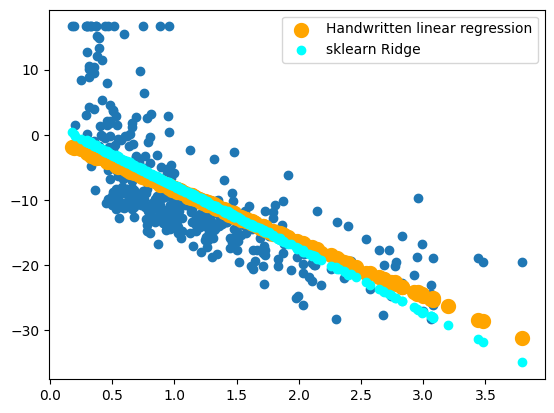

In [30]:
plt.scatter(x_n[:, -1], y_n[:, -1])
plt.scatter(
    x_n[:, -1],
    x_n.dot(w_grad)[:, -1],
    color="orange",
    label="Handwritten linear regression",
    linewidth=5,
)
plt.scatter(x_n[:, -1], lr.predict(x_n), color="cyan", label="sklearn Ridge")
plt.legend()
plt.show()

If there are small differences in the obtained solutions, this is not a problem. The model based on your implementation does not use a bias term (it is equal to $0$), while the version from `sklearn` adjusts it as well.

### Submission
Submit the implemented `LossAndDerivatives` class to your github. To do this, you can copy the entire code cell (including the `numpy` import) to the `derivatives.py` file.

This completes the assignment. Congratulations!